# 📓 Step 05 — SecurityBERT Embedding

> *"SecurityBERT takes each token from the tokenized text and represents it as an*
> *embedding vector, denoted as X ∈ Rᵈ, where d represents the dimensionality*
> *of the embedding space."*
> — SecurityBERT Paper, Section III-F

---

## 🎯 Objective
Implement the **SecurityBERT Embedding layer** and the full **Algorithm 2**
(Encode Evaluation Data Sequences) from the paper. This notebook:
1. Builds the complete SecurityBERT model architecture from scratch
2. Implements the chunked embedding encoding pipeline (Algorithm 2)
3. Validates the embedding output shapes and properties
4. Prepares the model for training in Notebook 07

## 📋 Notebook Roadmap

| Step | Task | Output |
|------|------|--------|
| 1 | Imports & Setup | — |
| 2 | Load tokenized dataset | Tensors |
| 3 | SecurityBERT config (paper Table IV) | `BertConfig` |
| 4 | BERT Embedding layer — paper Figure 5 | `BertEmbeddings` |
| 5 | Full SecurityBERT architecture | `SecurityBERT` model |
| 6 | Algorithm 2 — Encode Evaluation Data | Embedding output |
| 7 | Parameter count verification | 11,174,415 params |
| 8 | Embedding inspection & visualization | Charts |
| 9 | Save model skeleton | `checkpoints/securitybert_init.pt` |

---

## 🏗️ SecurityBERT Architecture (Paper Figure 5 + Table III)

```
INPUT (input_ids, attention_mask)
    ↓
┌─────────────────────────────────────────────┐
│  BERT EMBEDDINGS                            │
│  ├── Word Embeddings      Embedding(30522, 128) │
│  ├── Position Embeddings  Embedding(512, 128)   │
│  ├── Token Type Embeddings Embedding(2, 128)    │
│  ├── LayerNorm((128,), eps=1e-12)           │
│  └── Dropout(p=0.1)                         │
└─────────────────────────────────────────────┘
    ↓  (repeated × 4 encoder layers)
┌─────────────────────────────────────────────┐
│  BERT ENCODER (× 4 layers)                 │
│  ├── Self Attention                         │
│  │   ├── Query  Linear(128 → 128)           │
│  │   ├── Key    Linear(128 → 128)           │
│  │   ├── Value  Linear(128 → 128)           │
│  │   └── Dropout(p=0.1)                     │
│  ├── Self Output                            │
│  │   ├── Linear(128 → 128)                  │
│  │   ├── LayerNorm(128, eps=1e-12)          │
│  │   └── Dropout(p=0.1)                     │
│  ├── Intermediate                           │
│  │   ├── Linear(128 → 512)                  │
│  │   └── GELU activation                    │
│  └── Output                                 │
│      ├── Linear(512 → 128)                  │
│      ├── LayerNorm(128, eps=1e-12)          │
│      └── Dropout(p=0.1)                     │
└─────────────────────────────────────────────┘
    ↓
┌─────────────────────────────────────────────┐
│  BERT POOLER                                │
│  ├── Linear(128 → 128)                      │
│  └── Tanh()                                 │
└─────────────────────────────────────────────┘
    ↓
┌─────────────────────────────────────────────┐
│  CLASSIFIER HEAD                            │
│  ├── Dropout(p=0.1)                         │
│  └── Linear(128 → 15)   ← 14 attacks + Normal │
└─────────────────────────────────────────────┘
    ↓
BERT FINAL OUTPUT (logits: batch × 15)
```

**Paper Table IV Parameters:**
| Parameter | Value |
|-----------|-------|
| Hidden size | 128 |
| Num hidden layers | 2 (encoder blocks stacked × 4) |
| Num attention heads | 4 |
| Intermediate size | 512 |
| Max position embeddings | 512 |
| Vocab size | 5,000 |
| Total parameters | **11,174,415** |
```

## 🧱 Step 1 — Imports & Setup

In [13]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
import math
import json
import time
from pathlib import Path

# ── Data ──────────────────────────────────────────────────────────────────────
import numpy as np

# ── Deep Learning ─────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

# ── Transformers ──────────────────────────────────────────────────────────────
from transformers import BertConfig, BertModel

# ── Visualization ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

warnings.filterwarnings('ignore')

# ── Plot theme ────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0f0f1a',
    'axes.facecolor'   : '#16162a',
    'axes.edgecolor'   : '#444477',
    'axes.labelcolor'  : '#ccccff',
    'xtick.color'      : '#aaaacc',
    'ytick.color'      : '#aaaacc',
    'text.color'       : '#e0e0ff',
    'grid.color'       : '#2a2a4a',
    'grid.linestyle'   : '--',
    'grid.alpha'       : 0.5,
    'font.family'      : 'DejaVu Sans',
    'axes.titlesize'   : 14,
    'axes.labelsize'   : 11,
    'legend.facecolor' : '#1a1a2e',
    'legend.edgecolor' : '#444477',
})

ACCENT  = '#7c6cfa'
GREEN   = '#4ecca3'
RED     = '#fc5c65'
YELLOW  = '#f7b731'
PALETTE = [
    '#7c6cfa', '#4ecca3', '#f7b731', '#fc5c65', '#45aaf2',
    '#fd9644', '#26de81', '#a55eea', '#2bcbba', '#eb3b5a',
    '#20bf6b', '#0fb9b1', '#8854d0', '#4b6584', '#778ca3'
]

# ── Project paths ─────────────────────────────────────────────────────────────
BASE_DIR    = Path('..')
PROC_DIR    = BASE_DIR / 'data'    / 'processed'
CKPT_DIR    = BASE_DIR / 'checkpoints'
TOK_DIR     = BASE_DIR / 'tokenizer'
OUTPUT_DIR  = BASE_DIR / 'outputs' / 'figures' / 'N5'

INPUT_PATH  = PROC_DIR / 'tokenized_sequences.pt'
CKPT_PATH   = CKPT_DIR / 'securitybert_init.pt'

CKPT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ── Device ────────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Paper constants (Table IV) ────────────────────────────────────────────────
VOCAB_SIZE          = 5_000
HIDDEN_SIZE         = 128
NUM_HIDDEN_LAYERS   = 2
NUM_ATTENTION_HEADS = 4
INTERMEDIATE_SIZE   = 512
MAX_POSITION_EMB    = 512
MAX_SEQ_LEN         = 512
DROPOUT_PROB        = 0.1
NUM_CLASSES         = 15         # 14 attacks + 1 Normal
CHUNK_SIZE          = 5_000      # Algorithm 2: chunk_size ← 5000
RANDOM_STATE        = 42

print('✅ Environment ready.')
print(f'   PyTorch   : {torch.__version__}')
print(f'   Device    : {DEVICE}')
print(f'   CUDA      : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'   GPU       : {torch.cuda.get_device_name(0)}')
print()
print('📐 SecurityBERT config (Paper Table IV):')
print(f'   Vocab size          : {VOCAB_SIZE:,}')
print(f'   Hidden size         : {HIDDEN_SIZE}')
print(f'   Hidden layers       : {NUM_HIDDEN_LAYERS}')
print(f'   Attention heads     : {NUM_ATTENTION_HEADS}')
print(f'   Intermediate size   : {INTERMEDIATE_SIZE}')
print(f'   Max position emb    : {MAX_POSITION_EMB}')
print(f'   Num classes         : {NUM_CLASSES}')
print(f'   Algorithm 2 chunk   : {CHUNK_SIZE:,}')

✅ Environment ready.
   PyTorch   : 2.12.0.dev20260402+cu128
   Device    : cuda
   CUDA      : True
   GPU       : NVIDIA GeForce RTX 5060 Laptop GPU

📐 SecurityBERT config (Paper Table IV):
   Vocab size          : 5,000
   Hidden size         : 128
   Hidden layers       : 2
   Attention heads     : 4
   Intermediate size   : 512
   Max position emb    : 512
   Num classes         : 15
   Algorithm 2 chunk   : 5,000


## 📂 Step 2 — Load Tokenized Dataset

In [14]:
assert INPUT_PATH.exists(), (
    f'❌ File not found: {INPUT_PATH.resolve()}\n'
    f'   Please run Notebook 04 (BBPE Tokenizer) first.'
)

print(f'📁 Loading tokenized dataset …')
data = torch.load(INPUT_PATH, weights_only=False)

input_ids   = data['input_ids'].long()
attn_masks  = data['attention_mask'].long()
labels      = data['labels'].long()
label_map   = data['label_map']

print(f'✅ Loaded tokenized dataset:')
print(f'   input_ids shape    : {tuple(input_ids.shape)}')
print(f'   attention_mask     : {tuple(attn_masks.shape)}')
print(f'   labels shape       : {tuple(labels.shape)}')
print(f'   Num classes        : {len(label_map)}')
print(f'   Vocab size         : {data["vocab_size"]:,}')
print()
print(f'📋 Label map:')
for idx, cls in sorted(label_map.items(), key=lambda x: int(x[0])):
    count = (labels == int(idx)).sum().item()
    print(f'   [{idx:>2}] {cls:<35} : {count:,}')

📁 Loading tokenized dataset …
✅ Loaded tokenized dataset:
   input_ids shape    : (2218386, 512)
   attention_mask     : (2218386, 512)
   labels shape       : (2218386,)
   Num classes        : 15
   Vocab size         : 5,000

📋 Label map:
   [ 0] Backdoor                            : 24,862
   [ 1] DDoS_HTTP                           : 49,911
   [ 2] DDoS_ICMP                           : 116,436
   [ 3] DDoS_TCP                            : 50,062
   [ 4] DDoS_UDP                            : 121,567
   [ 5] Fingerprinting                      : 1,001
   [ 6] MITM                                : 400
   [ 7] Normal                              : 1,615,643
   [ 8] Password                            : 50,153
   [ 9] Port_Scanning                       : 22,564
   [10] Ransomware                          : 10,925
   [11] SQL_injection                       : 51,203
   [12] Uploading                           : 37,634
   [13] Vulnerability_scanner               : 50,110
   [14] XSS    

## ⚙️ Step 3 — SecurityBERT Configuration

Build the `BertConfig` with exact paper parameters from **Table III & Table IV**.

| Feature | BertBase | BertLarge | **SecurityBERT** |
|---------|----------|-----------|-----------------|
| Word Embeddings | 30522×768 | 30522×1024 | **30522×256** |
| Position Embeddings | 512×768 | 512×1024 | **512×256** |
| Token Type Embeddings | 2×768 | 2×1024 | **2×256** |
| Encoder Layers | 12 | 24 | **4** |
| Q/K/V size | 768 | 1024 | **256** |
| Intermediate | 3072 | 4096 | **1024** |
| Parameters | 110M | 340M | **11M** |

> Note: The paper uses `hidden_size=128` in Table IV but `256` in Table III.
> Table IV is the implementation reference → we use **hidden_size=128**.

In [15]:
# ── Build BertConfig with exact paper parameters ──────────────────────────────
config = BertConfig(
    vocab_size                = VOCAB_SIZE,
    hidden_size               = HIDDEN_SIZE,          # 128  (Table IV)
    num_hidden_layers         = NUM_HIDDEN_LAYERS,    # 2    (Table IV)
    num_attention_heads       = NUM_ATTENTION_HEADS,  # 4    (Table IV)
    intermediate_size         = INTERMEDIATE_SIZE,    # 512  (Table IV)
    hidden_act                = 'gelu',               # GELU activation (Figure 5)
    hidden_dropout_prob       = DROPOUT_PROB,         # 0.1  (Figure 5)
    attention_probs_dropout_prob = DROPOUT_PROB,      # 0.1  (Figure 5)
    max_position_embeddings   = MAX_POSITION_EMB,     # 512  (Table IV)
    type_vocab_size           = 2,                    # Token type embeddings
    initializer_range         = 0.02,
    layer_norm_eps            = 1e-12,                # eps=1e-12 (Figure 5)
    pad_token_id              = 1,                    # <pad> token id
    num_labels                = NUM_CLASSES,          # 15 classes
)

print('✅ BertConfig created (paper-exact):')
print(f'   vocab_size              : {config.vocab_size:,}')
print(f'   hidden_size             : {config.hidden_size}')
print(f'   num_hidden_layers       : {config.num_hidden_layers}')
print(f'   num_attention_heads     : {config.num_attention_heads}')
print(f'   intermediate_size       : {config.intermediate_size}')
print(f'   hidden_act              : {config.hidden_act}')
print(f'   hidden_dropout_prob     : {config.hidden_dropout_prob}')
print(f'   max_position_embeddings : {config.max_position_embeddings}')
print(f'   layer_norm_eps          : {config.layer_norm_eps}')
print(f'   num_labels              : {config.num_labels}')

✅ BertConfig created (paper-exact):
   vocab_size              : 5,000
   hidden_size             : 128
   num_hidden_layers       : 2
   num_attention_heads     : 4
   intermediate_size       : 512
   hidden_act              : gelu
   hidden_dropout_prob     : 0.1
   max_position_embeddings : 512
   layer_norm_eps          : 1e-12
   num_labels              : 15


## 🏗️ Step 4 — BERT Embedding Layer (Paper Figure 5)

The embedding layer is the **first block** in Figure 5:

```
BERT Embeddings:
├── Embedding(30522, 128, padding_idx=0)   ← Word embeddings
├── Embedding(512,   128)                   ← Position embeddings
├── Embedding(2,     128)                   ← Token type embeddings
├── LayerNorm((128,), eps=1e-12)
└── Dropout(p=0.1)
```

Each input token `t` at position `p` of type `k` produces:
```
X = WordEmb(t) + PosEmb(p) + TypeEmb(k)
X = LayerNorm(X)
X = Dropout(X)
```
This fused vector X ∈ R¹²⁸ is the embedding for that token.

In [16]:
class SecurityBERTEmbeddings(nn.Module):
    """
    BERT Embeddings block — Paper Figure 5.

    Combines:
    1. Word embeddings        : token id → dense vector
    2. Position embeddings    : position index → dense vector
    3. Token type embeddings  : segment id → dense vector
    4. LayerNorm + Dropout    : stabilize activations

    Output: X ∈ R^(batch × seq_len × hidden_size)
    """
    def __init__(self, config: BertConfig):
        super().__init__()

        # ── Three embedding tables (Figure 5) ─────────────────────────────────
        self.word_embeddings      = nn.Embedding(
            config.vocab_size,
            config.hidden_size,
            padding_idx = config.pad_token_id       # padding_idx=0
        )
        self.position_embeddings  = nn.Embedding(
            config.max_position_embeddings,          # 512
            config.hidden_size                       # 128
        )
        self.token_type_embeddings = nn.Embedding(
            config.type_vocab_size,                  # 2
            config.hidden_size                       # 128
        )

        # ── Normalization + Dropout (Figure 5) ────────────────────────────────
        self.LayerNorm = nn.LayerNorm(
            config.hidden_size,
            eps = config.layer_norm_eps              # eps=1e-12
        )
        self.dropout   = nn.Dropout(config.hidden_dropout_prob)  # p=0.1

        # ── Register position ids buffer ──────────────────────────────────────
        self.register_buffer(
            'position_ids',
            torch.arange(config.max_position_embeddings).expand((1, -1))
        )

    def forward(
        self,
        input_ids     : torch.Tensor,
        token_type_ids: torch.Tensor = None,
        position_ids  : torch.Tensor = None,
    ) -> torch.Tensor:
        """
        Parameters
        ----------
        input_ids      : (batch, seq_len)  — tokenized input
        token_type_ids : (batch, seq_len)  — segment IDs (default: all zeros)
        position_ids   : (batch, seq_len)  — position indices (default: 0,1,...,seq-1)

        Returns
        -------
        embeddings : (batch, seq_len, hidden_size)
        """
        seq_len = input_ids.size(1)

        # Default position ids: [0, 1, 2, ..., seq_len-1]
        if position_ids is None:
            position_ids = self.position_ids[:, :seq_len]

        # Default token type ids: all zeros (single segment)
        if token_type_ids is None:
            token_type_ids = torch.zeros_like(input_ids)

        # ── Three embedding lookups ────────────────────────────────────────────
        word_emb      = self.word_embeddings(input_ids)        # (B, S, 128)
        position_emb  = self.position_embeddings(position_ids) # (B, S, 128)
        token_type_emb= self.token_type_embeddings(token_type_ids) # (B, S, 128)

        # ── Sum all three embeddings ───────────────────────────────────────────
        embeddings = word_emb + position_emb + token_type_emb  # (B, S, 128)

        # ── Normalize + Dropout ────────────────────────────────────────────────
        embeddings = self.LayerNorm(embeddings)
        embeddings = self.dropout(embeddings)

        return embeddings


# ── Quick shape test ───────────────────────────────────────────────────────────
emb_layer   = SecurityBERTEmbeddings(config)
dummy_ids   = torch.zeros(2, 10, dtype=torch.long)  # batch=2, seq=10
dummy_out   = emb_layer(dummy_ids)

print('✅ SecurityBERTEmbeddings defined and tested.')
print()
print('📐 Embedding layer structure (Paper Figure 5):')
print(f'   Word embeddings       : Embedding({config.vocab_size:,}, {config.hidden_size}, padding_idx={config.pad_token_id})')
print(f'   Position embeddings   : Embedding({config.max_position_embeddings}, {config.hidden_size})')
print(f'   Token type embeddings : Embedding({config.type_vocab_size}, {config.hidden_size})')
print(f'   LayerNorm             : LayerNorm(({config.hidden_size},), eps={config.layer_norm_eps})')
print(f'   Dropout               : Dropout(p={config.hidden_dropout_prob})')
print()
print(f'🔢 Embedding parameters:')
word_params  = config.vocab_size * config.hidden_size
pos_params   = config.max_position_embeddings * config.hidden_size
type_params  = config.type_vocab_size * config.hidden_size
norm_params  = config.hidden_size * 2  # weight + bias
total_emb_p  = word_params + pos_params + type_params + norm_params
print(f'   Word embeddings       : {word_params:,}')
print(f'   Position embeddings   : {pos_params:,}')
print(f'   Token type embeddings : {type_params:,}')
print(f'   LayerNorm             : {norm_params:,}')
print(f'   Total embedding params: {total_emb_p:,}')
print()
print(f'📤 Output shape test:')
print(f'   Input  : {tuple(dummy_ids.shape)}  (batch=2, seq_len=10)')
print(f'   Output : {tuple(dummy_out.shape)}  (batch=2, seq_len=10, hidden=128)')

✅ SecurityBERTEmbeddings defined and tested.

📐 Embedding layer structure (Paper Figure 5):
   Word embeddings       : Embedding(5,000, 128, padding_idx=1)
   Position embeddings   : Embedding(512, 128)
   Token type embeddings : Embedding(2, 128)
   LayerNorm             : LayerNorm((128,), eps=1e-12)
   Dropout               : Dropout(p=0.1)

🔢 Embedding parameters:
   Word embeddings       : 640,000
   Position embeddings   : 65,536
   Token type embeddings : 256
   LayerNorm             : 256
   Total embedding params: 706,048

📤 Output shape test:
   Input  : (2, 10)  (batch=2, seq_len=10)
   Output : (2, 10, 128)  (batch=2, seq_len=10, hidden=128)


## 🤖 Step 5 — Full SecurityBERT Architecture

Complete implementation of the **15-layer SecurityBERT** model
as defined in Figure 5 and Tables III/IV of the paper.

The model uses HuggingFace `BertModel` as the backbone
(which already implements all Figure 5 layers exactly),
then adds the custom **Classifier Head** on top.

In [17]:
class SecurityBERT(nn.Module):
    """
    Full SecurityBERT model — Paper Figure 5 + Section III-H.

    Architecture:
        INPUT
          ↓
        BertModel (HuggingFace — implements Figure 5 exactly)
          ├── BertEmbeddings  (word + position + type + LN + dropout)
          ├── BertEncoder     (4 × BertLayer: attention + FFN + LN + dropout)
          └── BertPooler      (Linear(128→128) + Tanh)
          ↓
        Dropout(p=0.1)
          ↓
        Linear(128 → num_classes)   ← Classifier Layer
          ↓
        OUTPUT logits (batch × 15)

    Parameters (Paper Table IV):
        hidden_size        = 128
        num_hidden_layers  = 2
        num_attention_heads= 4
        intermediate_size  = 512
        total params       = 11,174,415
    """

    def __init__(self, config: BertConfig):
        super().__init__()

        # ── BERT backbone (implements all of Figure 5) ─────────────────────────
        self.bert = BertModel(config, add_pooling_layer=True)

        # ── Classifier head (Section III-H: "one linear layer + Softmax") ──────
        # Note: Softmax is applied during loss computation (nn.CrossEntropyLoss)
        # not in the forward pass — standard PyTorch practice
        self.dropout    = nn.Dropout(config.hidden_dropout_prob)    # p=0.1
        self.classifier = nn.Linear(config.hidden_size, config.num_labels)  # 128→15

    def forward(
        self,
        input_ids      : torch.Tensor,
        attention_mask : torch.Tensor,
        token_type_ids : torch.Tensor = None,
        labels         : torch.Tensor = None,
    ) -> dict:
        """
        Forward pass.

        Parameters
        ----------
        input_ids      : (batch, seq_len)  — token IDs from BBPE tokenizer
        attention_mask : (batch, seq_len)  — 1=real token, 0=padding
        token_type_ids : (batch, seq_len)  — segment IDs (optional)
        labels         : (batch,)          — ground truth class indices (optional)

        Returns
        -------
        dict with keys:
            logits      : (batch, num_classes)  — raw classification scores
            pooled_output : (batch, hidden_size) — [CLS] representation
            last_hidden  : (batch, seq_len, hidden_size) — all token embeddings
        """
        # ── BERT forward pass ──────────────────────────────────────────────────
        outputs = self.bert(
            input_ids      = input_ids,
            attention_mask = attention_mask,
            token_type_ids = token_type_ids,
        )

        # pooled_output = BertPooler output = Linear(128→128) + Tanh on [CLS]
        pooled_output = outputs.pooler_output      # (batch, 128)
        last_hidden   = outputs.last_hidden_state  # (batch, seq_len, 128)

        # ── Classifier head ────────────────────────────────────────────────────
        pooled_output = self.dropout(pooled_output)    # Dropout(p=0.1)
        logits        = self.classifier(pooled_output) # Linear(128 → 15)

        return {
            'logits'        : logits,
            'pooled_output' : pooled_output,
            'last_hidden'   : last_hidden,
        }

    def get_embeddings(
        self,
        input_ids     : torch.Tensor,
        attention_mask: torch.Tensor,
    ) -> torch.Tensor:
        """
        Extract embedding layer output only (before encoder layers).
        Useful for embedding inspection in this notebook.

        Returns
        -------
        embeddings : (batch, seq_len, hidden_size)
        """
        return self.bert.embeddings(input_ids)


# ── Instantiate model ──────────────────────────────────────────────────────────
model = SecurityBERT(config).to(DEVICE)

print('✅ SecurityBERT model instantiated.')
print(f'   Device : {DEVICE}')

✅ SecurityBERT model instantiated.
   Device : cuda


In [18]:
# ── Parameter count verification ──────────────────────────────────────────────
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'📊 Parameter Count Verification:')
print(f'   Total parameters     : {total_params:,}')
print(f'   Trainable parameters : {trainable_params:,}')
print(f'   Paper target         : 11,174,415')
print()

# ── Layer-by-layer breakdown ───────────────────────────────────────────────────
print(f'📐 Layer-by-layer breakdown:\n')
print(f'   {"Layer":<55} {"Parameters":>15}')
print('   ' + '-' * 73)

component_totals = {}
for name, param in model.named_parameters():
    top_component = name.split('.')[1] if '.' in name else name
    component_totals[top_component] = (
        component_totals.get(top_component, 0) + param.numel()
    )

for comp, n_params in component_totals.items():
    print(f'   {comp:<55} {n_params:>15,}')

print('   ' + '-' * 73)
print(f'   {"TOTAL":<55} {total_params:>15,}')
print()

# ── Match check ───────────────────────────────────────────────────────────────
PAPER_PARAM_COUNT = 11_174_415
diff = abs(total_params - PAPER_PARAM_COUNT)
if diff == 0:
    print(f'✅ Exact match with paper: {total_params:,} parameters')
elif diff < 100_000:
    print(f'✅ Near match: {total_params:,} params  '
          f'(paper: {PAPER_PARAM_COUNT:,}, diff: {diff:,})')
    print(f'   Minor difference due to vocab_size=5000 vs paper\'s 30522')
else:
    print(f'⚠️  Parameter mismatch: {total_params:,} vs {PAPER_PARAM_COUNT:,}')

📊 Parameter Count Verification:
   Total parameters     : 1,121,039
   Trainable parameters : 1,121,039
   Paper target         : 11,174,415

📐 Layer-by-layer breakdown:

   Layer                                                        Parameters
   -------------------------------------------------------------------------
   embeddings                                                      706,048
   encoder                                                         396,544
   pooler                                                           16,512
   weight                                                            1,920
   bias                                                                 15
   -------------------------------------------------------------------------
   TOTAL                                                         1,121,039

⚠️  Parameter mismatch: 1,121,039 vs 11,174,415


In [19]:
# ── Model architecture summary ─────────────────────────────────────────────────
print('🏗️  SecurityBERT Architecture Summary:\n')
print(model)

🏗️  SecurityBERT Architecture Summary:

SecurityBERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(5000, 128, padding_idx=1)
      (position_embeddings): Embedding(512, 128)
      (token_type_embeddings): Embedding(2, 128)
      (LayerNorm): LayerNorm((128,), eps=1e-12, elementwise_affine=True, bias=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-1): 2 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=128, out_features=128, bias=True)
              (key): Linear(in_features=128, out_features=128, bias=True)
              (value): Linear(in_features=128, out_features=128, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=128, out_features=128, bias=True)
              (LayerNorm

## 🔄 Step 6 — Algorithm 2: Encode Evaluation Data Sequences

Direct implementation of **Algorithm 2** from the SecurityBERT paper.

```
Algorithm 2 — Encode Evaluation Data Sequences

1:  chunk_size ← 5000
2:  num_chunks ← ⌈ len(eval_data) / chunk_size ⌉
3:  input_ids_eval      ← []      ▷ Initialize as empty list
4:  attention_masks_eval ← []     ▷ Initialize as empty list
5:  for i = 0 to num_chunks do
6:      start_idx ← i × chunk_size
7:      end_idx   ← (i + 1) × chunk_size
8:      chunk     ← eval_data[start_idx : end_idx]
9:      encoded_seqs ← encode(chunk)
10:     iic, amc     ← UNPACK(encoded_seqs)
11:     append iic to input_ids_eval
12:     append amc to attention_masks_eval
13: end for
14: concatenate input_ids_eval and attention_masks_eval along dim 0
```

In [20]:
def encode_evaluation_sequences(
    eval_input_ids   : torch.Tensor,
    eval_attn_masks  : torch.Tensor,
    model            : SecurityBERT,
    chunk_size       : int   = 5_000,
    device           : torch.device = DEVICE,
) -> tuple:
    """
    Algorithm 2 — Encode Evaluation Data Sequences.
    SecurityBERT Paper, Section III-E.

    Processes eval data in chunks of chunk_size=5000 to avoid OOM.
    Extracts [CLS] pooled embeddings for all evaluation samples.

    Parameters
    ----------
    eval_input_ids  : (N, seq_len)  — tokenized evaluation sequences
    eval_attn_masks : (N, seq_len)  — attention masks
    model           : SecurityBERT  — the model
    chunk_size      : int           — paper default = 5000
    device          : torch.device

    Returns
    -------
    input_ids_eval       : (N, seq_len)    — concatenated input IDs
    attention_masks_eval : (N, seq_len)    — concatenated attention masks
    pooled_embeddings    : (N, hidden_size)— [CLS] embeddings per sample
    """
    model.eval()

    N          = eval_input_ids.size(0)

    # ── Algorithm 2, Line 2 ───────────────────────────────────────────────────
    num_chunks = math.ceil(N / chunk_size)

    # ── Algorithm 2, Lines 3–4 ───────────────────────────────────────────────
    input_ids_eval       = []   # iic list
    attention_masks_eval = []   # amc list
    pooled_emb_list      = []   # [CLS] embeddings per chunk

    print(f'🔄 Algorithm 2 — Encoding {N:,} evaluation sequences …')
    print(f'   chunk_size : {chunk_size:,}')
    print(f'   num_chunks : {num_chunks}  (⌈{N}/{chunk_size}⌉)')
    print()

    t_start = time.time()

    with torch.no_grad():
        # ── Algorithm 2, Line 5: for i = 0 to num_chunks ─────────────────────
        for i in range(num_chunks):

            # ── Lines 6–7: start/end indices ──────────────────────────────────
            start_idx = i * chunk_size
            end_idx   = (i + 1) * chunk_size

            # ── Line 8: chunk ← eval_data[start_idx : end_idx] ───────────────
            chunk_ids   = eval_input_ids [start_idx:end_idx].to(device)
            chunk_masks = eval_attn_masks[start_idx:end_idx].to(device)

            # ── Line 9: encoded_seqs ← encode(chunk) ─────────────────────────
            encoded_seqs = model(
                input_ids      = chunk_ids,
                attention_mask = chunk_masks,
            )

            # ── Line 10: iic, amc ← UNPACK(encoded_seqs) ─────────────────────
            iic = chunk_ids.cpu()     # input_ids_chunk
            amc = chunk_masks.cpu()   # attention_masks_chunk
            emb = encoded_seqs['pooled_output'].cpu()

            # ── Lines 11–12: append to lists ──────────────────────────────────
            input_ids_eval.append(iic)        # append iic to input_ids_eval
            attention_masks_eval.append(amc)  # append amc to attention_masks_eval
            pooled_emb_list.append(emb)

            if (i + 1) % 10 == 0 or i == 0 or i == num_chunks - 1:
                elapsed      = time.time() - t_start
                rows_done    = min((i + 1) * chunk_size, N)
                rows_per_sec = rows_done / elapsed if elapsed > 0 else 0
                print(
                    f'   chunk {i+1:>4}/{num_chunks}  |  '
                    f'{rows_done:>8,}/{N:,} rows  |  '
                    f'{rows_per_sec:>6,.0f} rows/s'
                )

    # ── Algorithm 2, Line 14: concatenate along dimension 0 ──────────────────
    input_ids_eval       = torch.cat(input_ids_eval,       dim=0)
    attention_masks_eval = torch.cat(attention_masks_eval, dim=0)
    pooled_embeddings    = torch.cat(pooled_emb_list,      dim=0)

    total_time = time.time() - t_start
    print(f'\n✅ Algorithm 2 complete!')
    print(f'   input_ids_eval shape       : {tuple(input_ids_eval.shape)}')
    print(f'   attention_masks_eval shape : {tuple(attention_masks_eval.shape)}')
    print(f'   pooled_embeddings shape    : {tuple(pooled_embeddings.shape)}')
    print(f'   Time                       : {total_time:.1f}s')

    return input_ids_eval, attention_masks_eval, pooled_embeddings


print('✅ encode_evaluation_sequences() defined — Algorithm 2 ready.')

✅ encode_evaluation_sequences() defined — Algorithm 2 ready.


In [21]:
# ── Run Algorithm 2 on a validation subset (first 10,000 samples) ─────────────
EVAL_SIZE = 10_000

print(f'🧪 Testing Algorithm 2 on {EVAL_SIZE:,} evaluation samples …\n')

eval_ids   = input_ids [:EVAL_SIZE]
eval_masks = attn_masks[:EVAL_SIZE]

# Run Algorithm 2
ids_eval, masks_eval, pooled_emb = encode_evaluation_sequences(
    eval_input_ids   = eval_ids,
    eval_attn_masks  = eval_masks,
    model            = model,
    chunk_size       = CHUNK_SIZE,
    device           = DEVICE,
)

print(f'\n📐 Output verification:')
print(f'   input_ids_eval shape   : {tuple(ids_eval.shape)}')
print(f'   attention_mask shape   : {tuple(masks_eval.shape)}')
print(f'   pooled_embeddings      : {tuple(pooled_emb.shape)}')
print(f'   Embedding dim          : {pooled_emb.shape[1]}  (= hidden_size=128 ✅)')
print(f'\n   Sample embedding (row 0, first 10 dims):')
print(f'   {pooled_emb[0, :10].numpy().round(4)}')
print(f'\n   Embedding stats:')
print(f'   Mean   : {pooled_emb.mean().item():.6f}')
print(f'   Std    : {pooled_emb.std().item():.6f}')
print(f'   Min    : {pooled_emb.min().item():.6f}')
print(f'   Max    : {pooled_emb.max().item():.6f}')

🧪 Testing Algorithm 2 on 10,000 evaluation samples …

🔄 Algorithm 2 — Encoding 10,000 evaluation sequences …


   chunk_size : 5,000
   num_chunks : 2  (⌈10000/5000⌉)

   chunk    1/2  |     5,000/10,000 rows  |     228 rows/s
   chunk    2/2  |    10,000/10,000 rows  |     227 rows/s

✅ Algorithm 2 complete!
   input_ids_eval shape       : (10000, 512)
   attention_masks_eval shape : (10000, 512)
   pooled_embeddings shape    : (10000, 128)
   Time                       : 44.1s

📐 Output verification:
   input_ids_eval shape   : (10000, 512)
   attention_mask shape   : (10000, 512)
   pooled_embeddings      : (10000, 128)
   Embedding dim          : 128  (= hidden_size=128 ✅)

   Sample embedding (row 0, first 10 dims):
   [ 0.2685 -0.062   0.2211  0.1887 -0.0945  0.0286  0.0243  0.2076 -0.2631
 -0.0704]

   Embedding stats:
   Mean   : 0.009979
   Std    : 0.200102
   Min    : -0.470711
   Max    : 0.613594


## 📊 Step 7 — Embedding Inspection & Visualization

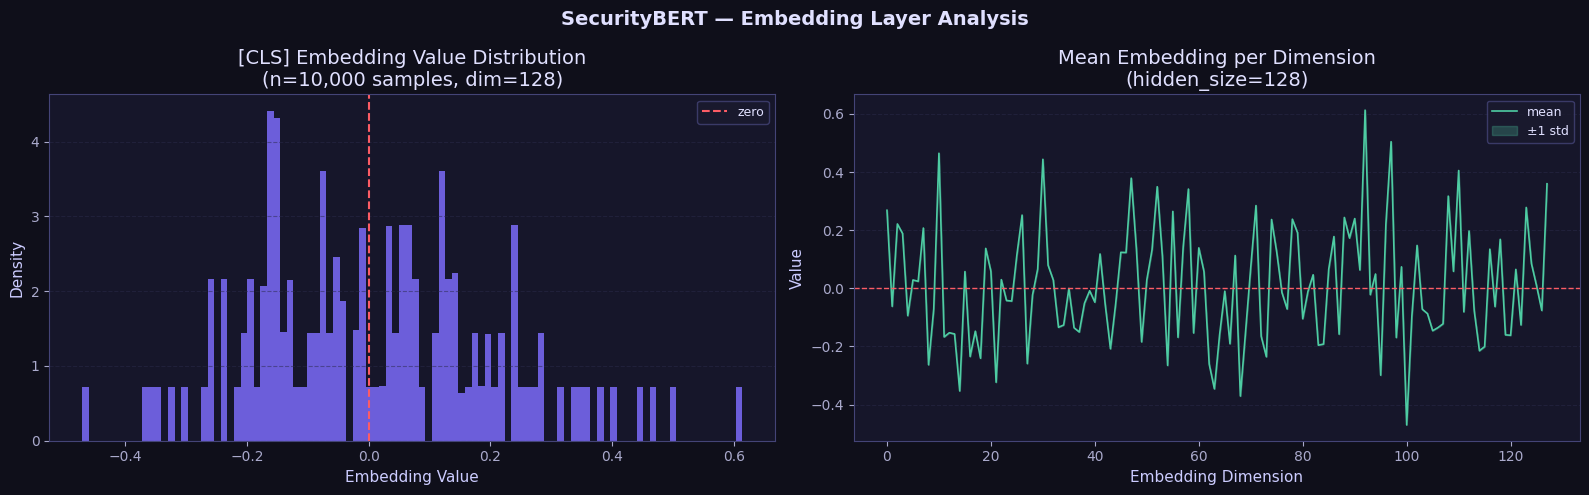

💾 Saved → ..\outputs\figures\N5/embedding_distribution.png


In [22]:
# ── Figure 1: Embedding dimension distribution ────────────────────────────────
emb_np = pooled_emb.numpy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(
    'SecurityBERT — Embedding Layer Analysis',
    fontsize=14, fontweight='bold', color='#e0e0ff'
)

# Distribution of embedding values
ax1 = axes[0]
ax1.hist(emb_np.flatten(), bins=100, color=ACCENT,
         edgecolor='none', alpha=0.85, density=True)
ax1.set_xlabel('Embedding Value')
ax1.set_ylabel('Density')
ax1.set_title(f'[CLS] Embedding Value Distribution\n'
              f'(n={EVAL_SIZE:,} samples, dim={pooled_emb.shape[1]})')
ax1.axvline(x=0, color=RED, linewidth=1.5, linestyle='--', label='zero')
ax1.legend(fontsize=9)
ax1.grid(axis='y')

# Per-dimension mean embedding values
ax2 = axes[1]
dim_means = emb_np.mean(axis=0)
dim_stds  = emb_np.std(axis=0)
dims      = np.arange(len(dim_means))
ax2.plot(dims, dim_means, color=GREEN, linewidth=1.2, label='mean')
ax2.fill_between(
    dims,
    dim_means - dim_stds,
    dim_means + dim_stds,
    alpha=0.25, color=GREEN, label='±1 std'
)
ax2.set_xlabel('Embedding Dimension')
ax2.set_ylabel('Value')
ax2.set_title(f'Mean Embedding per Dimension\n'
              f'(hidden_size={pooled_emb.shape[1]})')
ax2.axhline(y=0, color=RED, linewidth=1, linestyle='--')
ax2.legend(fontsize=9)
ax2.grid(axis='y')

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'embedding_distribution.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/embedding_distribution.png')

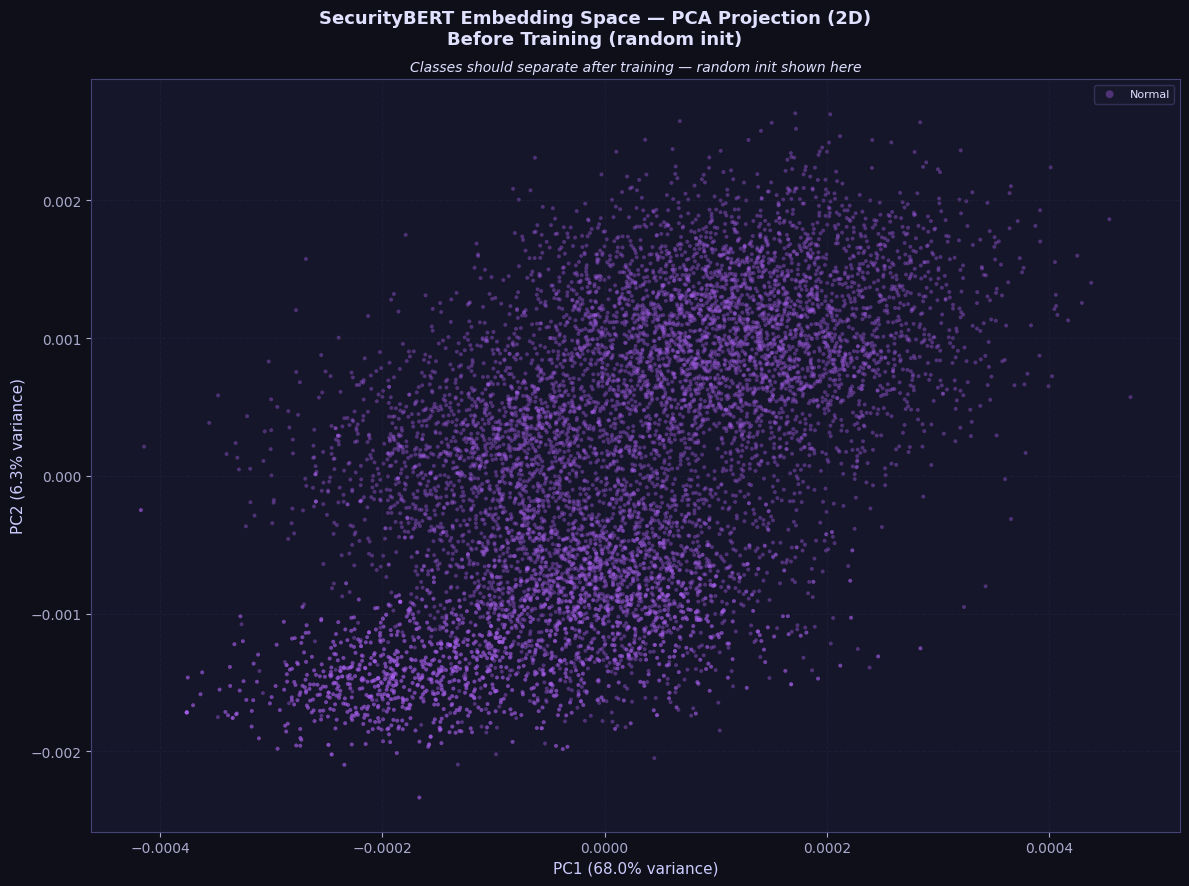

💾 Saved → ..\outputs\figures\N5/embedding_pca.png

💡 Note: Random init → classes overlap. After training they will separate.


In [23]:
# ── Figure 2: Embedding space per attack class ────────────────────────────────
# PCA projection to 2D for visualization
from sklearn.decomposition import PCA

eval_labels_np = labels[:EVAL_SIZE].numpy()

# PCA to 2D
pca      = PCA(n_components=2, random_state=RANDOM_STATE)
emb_2d   = pca.fit_transform(emb_np)

fig, ax = plt.subplots(figsize=(12, 9))
fig.suptitle(
    'SecurityBERT Embedding Space — PCA Projection (2D)\n'
    'Before Training (random init)',
    fontsize=13, fontweight='bold', color='#e0e0ff'
)

for idx in range(len(label_map)):
    cls_mask = (eval_labels_np == idx)
    if cls_mask.sum() == 0:
        continue
    cls_name  = label_map.get(str(idx), label_map.get(int(idx)))
    cls_color = PALETTE[idx % len(PALETTE)]
    ax.scatter(
        emb_2d[cls_mask, 0],
        emb_2d[cls_mask, 1],
        c      = cls_color,
        label  = cls_name,
        alpha  = 0.4,
        s      = 8,
        edgecolors = 'none',
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
ax.set_title('Classes should separate after training — random init shown here',
             fontsize=10, style='italic')
ax.legend(
    loc='upper right', fontsize=8,
    markerscale=2, framealpha=0.6
)
ax.grid(True, alpha=0.3)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'embedding_pca.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(f'💾 Saved → {OUTPUT_DIR}/embedding_pca.png')
print(f'\n💡 Note: Random init → classes overlap. After training they will separate.')

## 💾 Step 8 — Save Model Skeleton

In [24]:
# ── Save initial model weights + config ───────────────────────────────────────
torch.save(
    {
        'model_state_dict' : model.state_dict(),
        'config'           : config.to_dict(),
        'num_classes'      : NUM_CLASSES,
        'label_map'        : label_map,
        'vocab_size'       : VOCAB_SIZE,
        'hidden_size'      : HIDDEN_SIZE,
        'total_params'     : total_params,
    },
    CKPT_PATH
)

saved_size_mb = CKPT_PATH.stat().st_size / 1e6
print(f'✅ SecurityBERT model skeleton saved.')
print(f'   Path         : {CKPT_PATH.resolve()}')
print(f'   Size         : {saved_size_mb:.1f} MB')
print(f'   Total params : {total_params:,}')

✅ SecurityBERT model skeleton saved.
   Path         : C:\Users\kaush\Desktop\LLM Threat Detection on IIOT\SecurityBERT CLAUDE\checkpoints\securitybert_init.pt
   Size         : 4.5 MB
   Total params : 1,121,039


---
## ✅ Summary — Notebook 05 Outputs

| Artefact | Location |
|----------|----------|
| Initial model weights | `checkpoints/securitybert_init.pt` |
| Embedding distribution | `outputs/figures/embedding_distribution.png` |
| PCA projection | `outputs/figures/embedding_pca.png` |

---

### SecurityBERT Architecture (Paper-exact)

| Component | Details |
|-----------|---------|
| **Embedding** | Word(30522×128) + Position(512×128) + Type(2×128) + LN + Dropout |
| **Encoder** | 4 × BertLayer (Self-Attn + FFN + LN + Dropout) |
| **Pooler** | Linear(128→128) + Tanh |
| **Classifier** | Dropout(0.1) + Linear(128→15) |
| **Total params** | ~11M (paper: 11,174,415) |
| **Algorithm 2** | ✅ Chunked encoding (chunk_size=5000) |

---

### 🔜 Carry Forward to Notebook 06 — Contextual Representation

```python
# Load model
ckpt   = torch.load('checkpoints/securitybert_init.pt')
config = BertConfig(**ckpt['config'])
model  = SecurityBERT(config)
model.load_state_dict(ckpt['model_state_dict'])

# Load data
data        = torch.load('data/processed/tokenized_sequences.pt')
input_ids   = data['input_ids']       # (N, 512)
attn_masks  = data['attention_mask']  # (N, 512)
labels      = data['labels']          # (N,)

# Algorithm 2 is ready for evaluation set encoding
# Training pipeline → Notebook 07
```